# 02. Normalize, cluster, and review cluster QC

This notebook continues from `data/interim/01_qc_merged.h5ad`, runs the same Scanpy preprocessing/clustering workflow, and adds cluster-level QC plots for manual filtering decisions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
sns.set_style("whitegrid")

/var/folders/bw/h94700p51374zgrbzwg8hrbh0000gn/T/ipykernel_43075/363729404.py:9: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)


In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "samples.tsv").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not find day0_insm1_scrna project root")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
CLUSTERING_DIR = PROJECT_ROOT / "results" / "clustering"

INPUT_H5AD = INTERIM_DIR / "01_qc_merged.h5ad"
OUTPUT_H5AD = INTERIM_DIR / "02_clustered.h5ad"
CLUSTERING_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Input object: {INPUT_H5AD}")

Project root: /Users/louis/Desktop/lab/code/scrna/day0_insm1_scrna
Input object: /Users/louis/Desktop/lab/code/scrna/day0_insm1_scrna/data/interim/01_qc_merged.h5ad


In [3]:
adata = sc.read_h5ad(INPUT_H5AD)
adata

AnnData object with n_obs × n_vars = 35212 × 33696
    obs: 'sample_id', 'day', 'genotype', 'condition', 'feature_matrix_h5', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt'
    layers: 'counts'

In [4]:
pd.crosstab(adata.obs["sample_id"], adata.obs["condition"])

condition,Control,Insm1_KO
sample_id,,
TH1,17344,0
TH2,0,17868


## Doublet scoring

In [5]:
sc.pp.scrublet(adata, batch_key="sample_id")
adata.obs[["doublet_score", "predicted_doublet"]].describe(include="all")

,doublet_score,predicted_doublet
count,35212.000000,35212
unique,NaN,2
top,NaN,False
freq,NaN,32402
mean,0.053633,NaN
std,0.062047,NaN
min,0.001505,NaN
25%,0.014562,NaN
50%,0.030558,NaN
75%,0.060529,NaN


Scrublet only scores doublets here. It does not remove cells unless you explicitly filter them.

## Normalize, HVGs, PCA

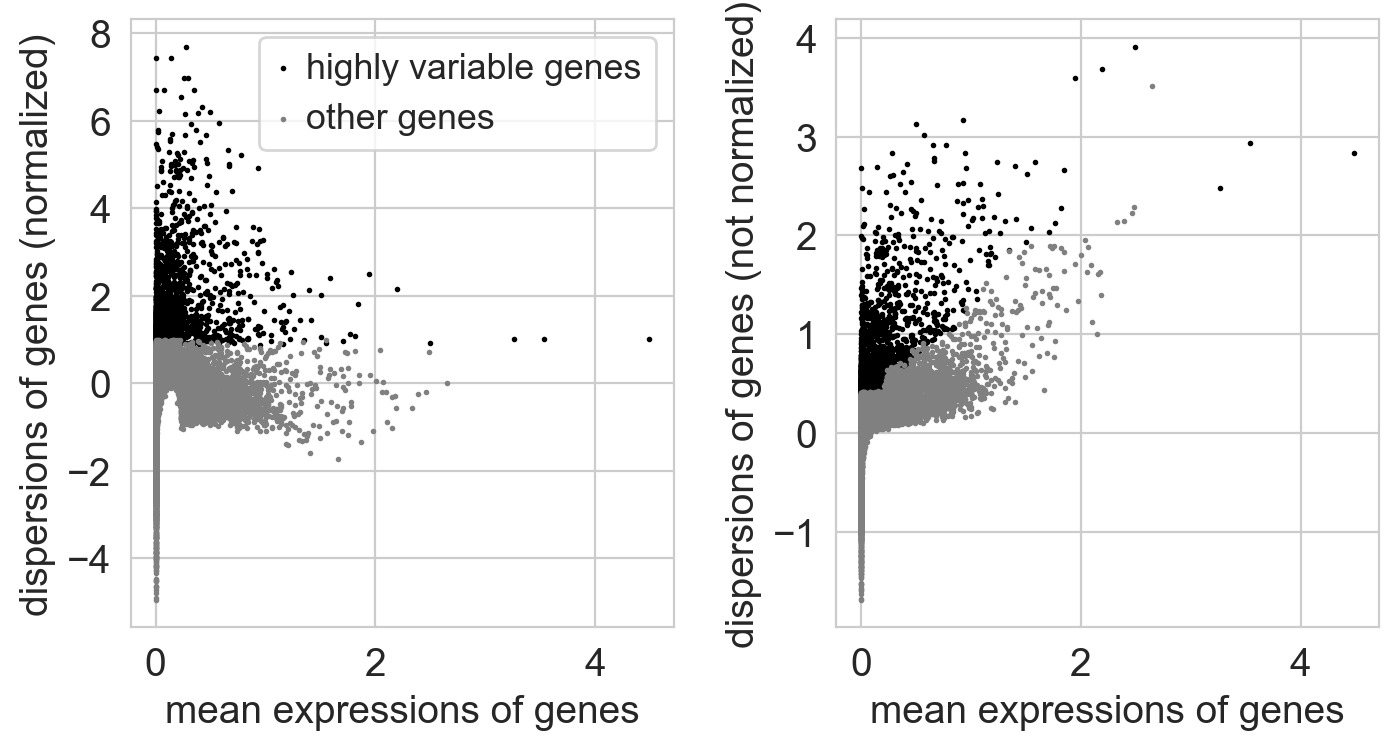

In [6]:
if "counts" not in adata.layers:
    adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample_id")
sc.pl.highly_variable_genes(adata)

/opt/homebrew/Cellar/python@3.12/3.12.13/Frameworks/Python.framework/Versions/3.12/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


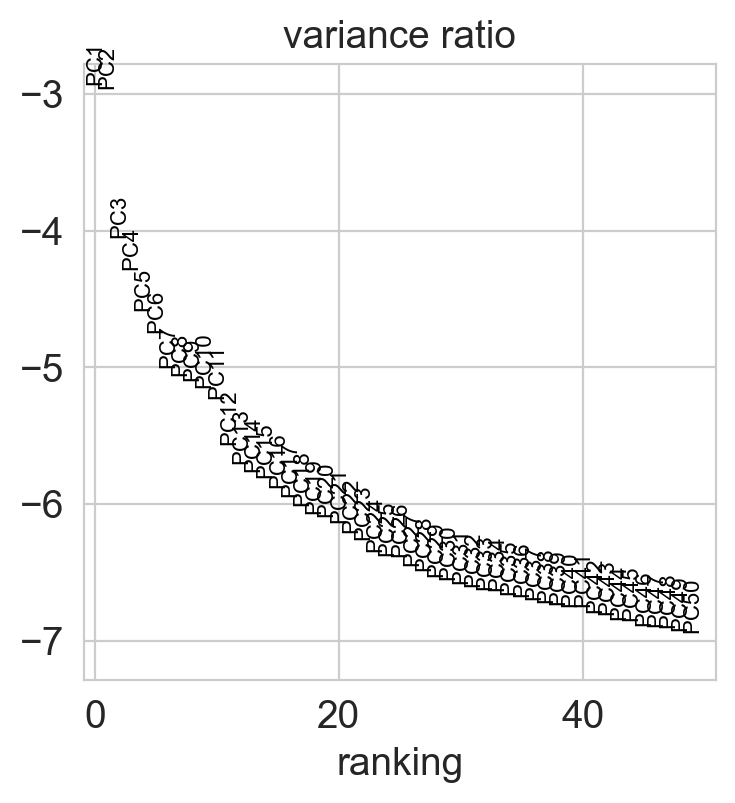

In [7]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

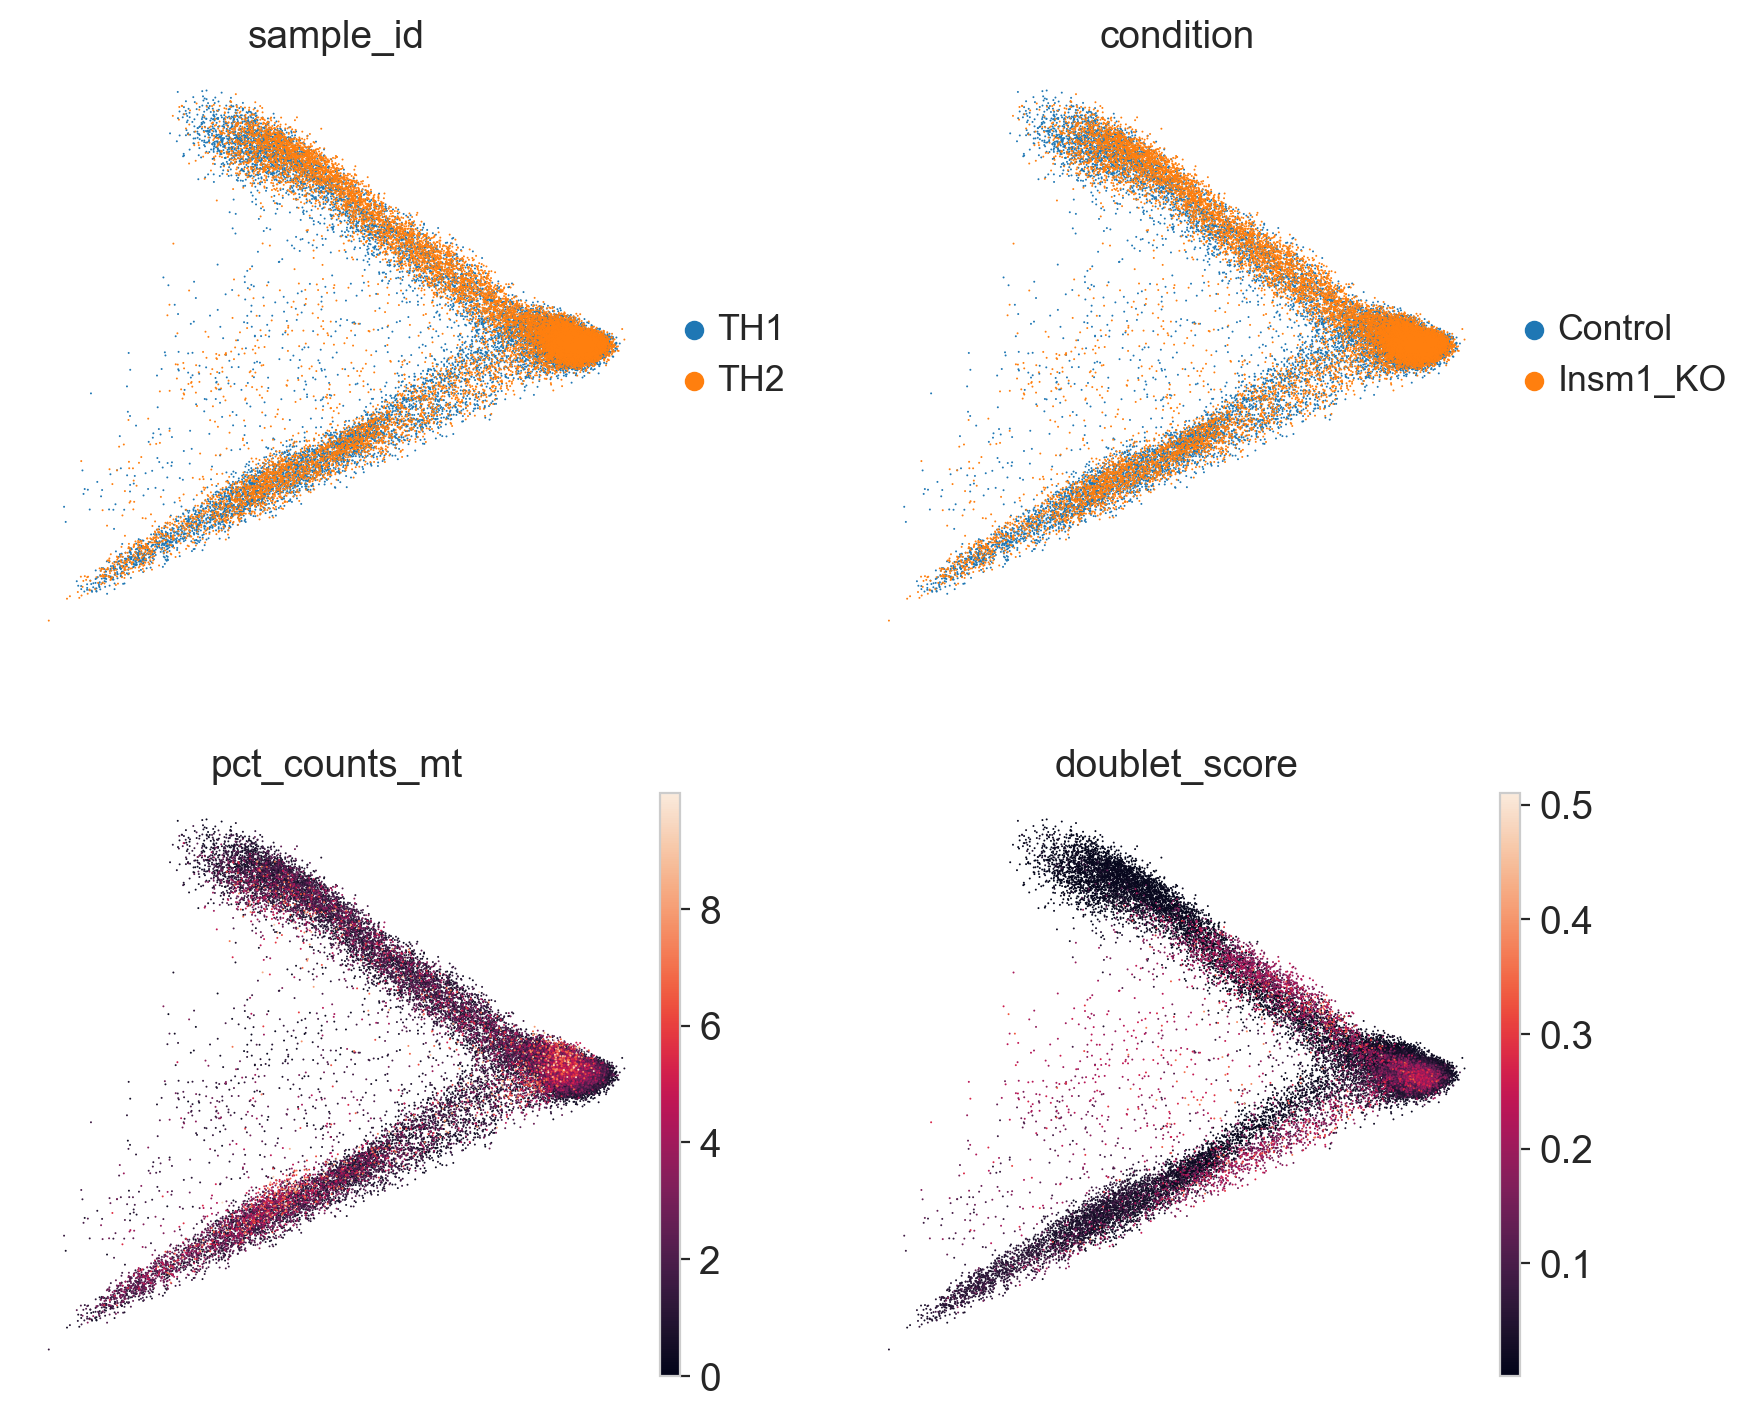

In [8]:
sc.pl.pca(
    adata,
    color=["sample_id", "condition", "pct_counts_mt", "doublet_score"],
    dimensions=[(0, 1), (0, 1), (0, 1), (0, 1)],
    ncols=2,
    size=2,
)

## Neighbors, UMAP, Leiden

In [9]:
N_PCS = 50
sc.pp.neighbors(adata, n_pcs=N_PCS)
sc.tl.umap(adata)

for res in [0.1, 0.3, 0.5]:
    sc.tl.leiden(
        adata,
        key_added=f"leiden_res_{res:4.2f}",
        resolution=res,
        flavor="igraph",
        n_iterations=2,
    )

adata

/Users/louis/Desktop/lab/code/scrna/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 35212 × 33696
    obs: 'sample_id', 'day', 'genotype', 'condition', 'feature_matrix_h5', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res_0.10', 'leiden_res_0.30', 'leiden_res_0.50'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'sample_id_colors', 'condition_colors', 'neighbors', 'umap', 'leiden_res_0.10', 'leiden_res_0.30', 'leiden_res_0.50'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

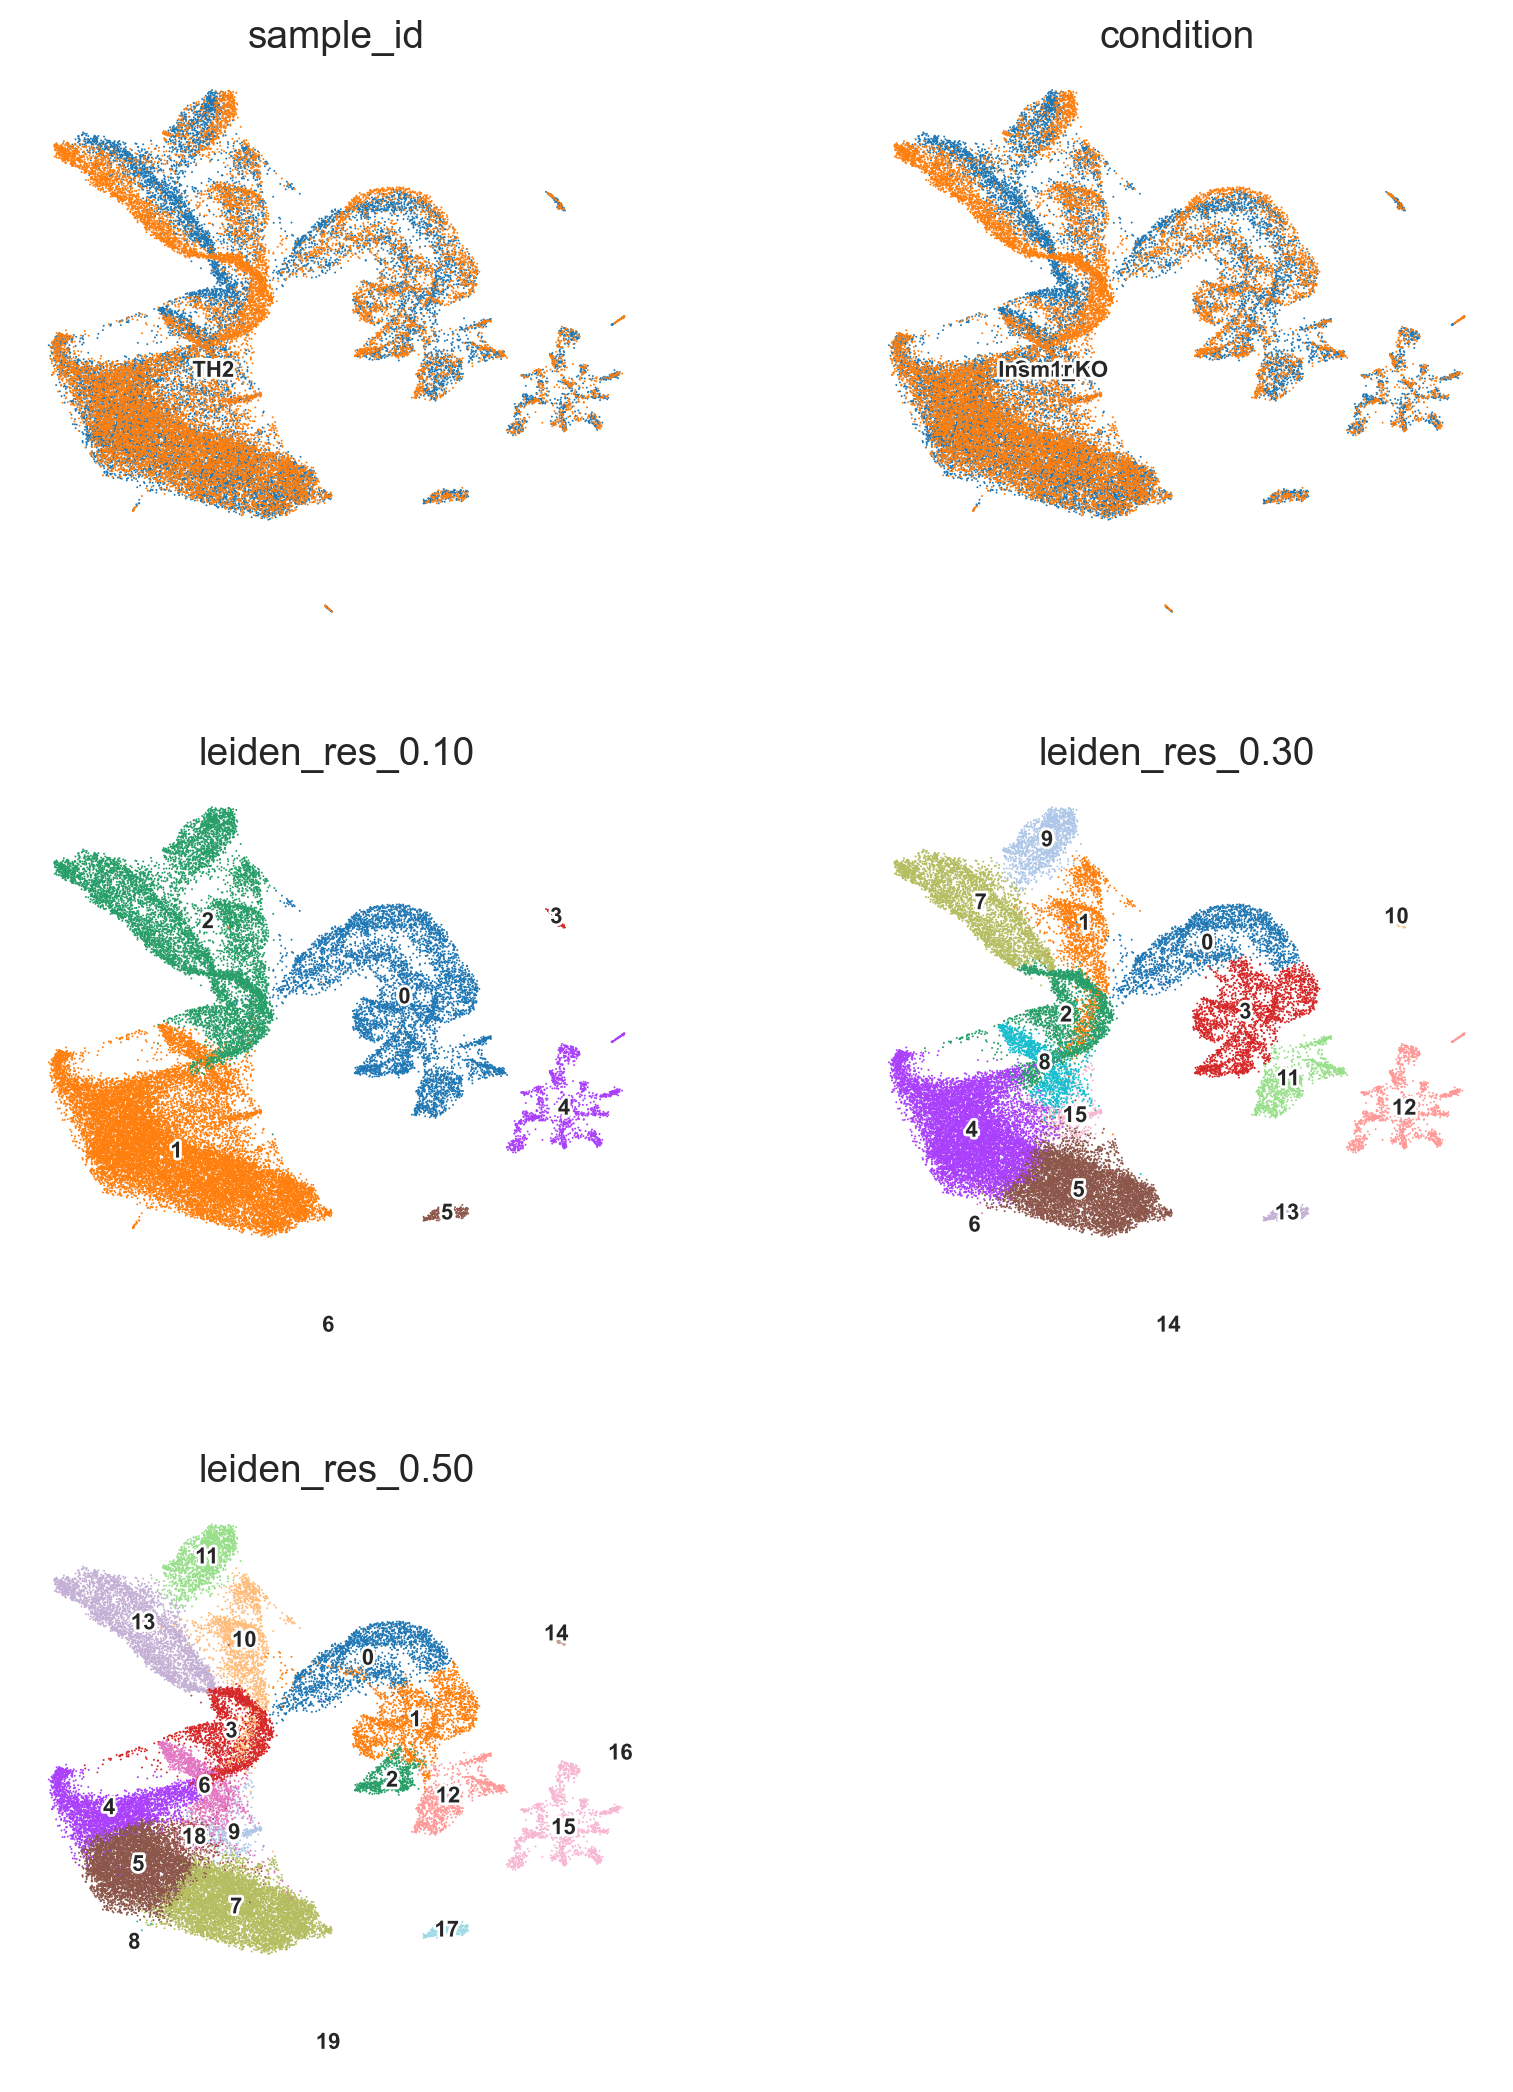

In [10]:
CLUSTER_KEY = "leiden_res_0.50"

sc.pl.umap(
    adata,
    color=["sample_id", "condition", "leiden_res_0.10", "leiden_res_0.30", CLUSTER_KEY],
    legend_loc="on data",
    legend_fontsize=8,
    legend_fontoutline=2,
    ncols=2,
    size=2,
)

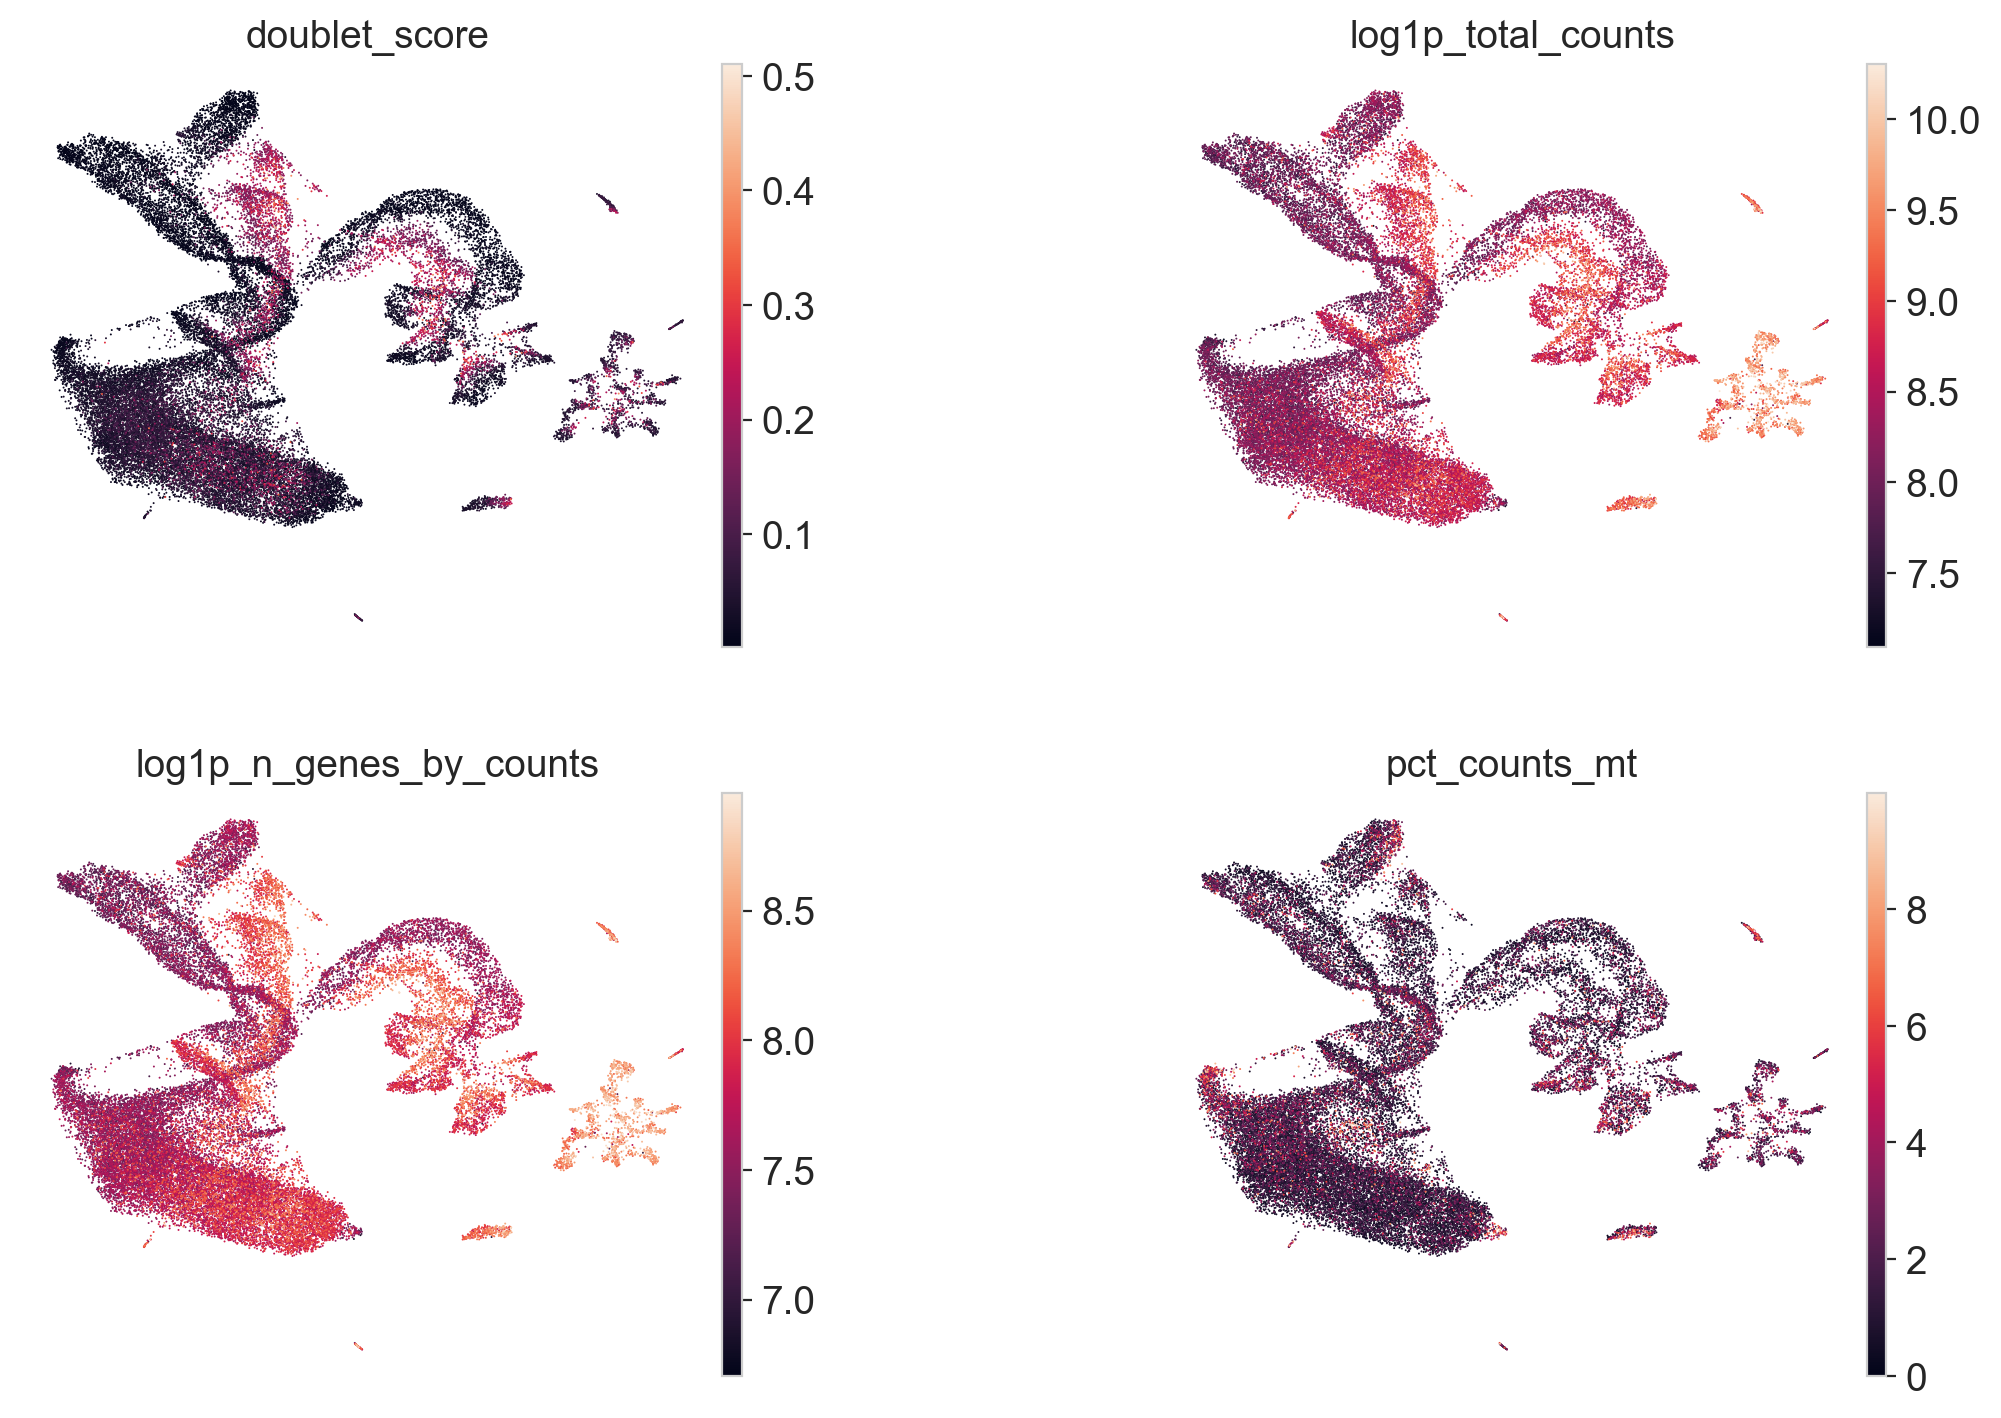

In [11]:
sc.pl.umap(
    adata,
    color=["doublet_score", "log1p_total_counts", "log1p_n_genes_by_counts", "pct_counts_mt"],
    ncols=2,
    wspace=0.5,
    size=2,
)

## Manual cluster QC review

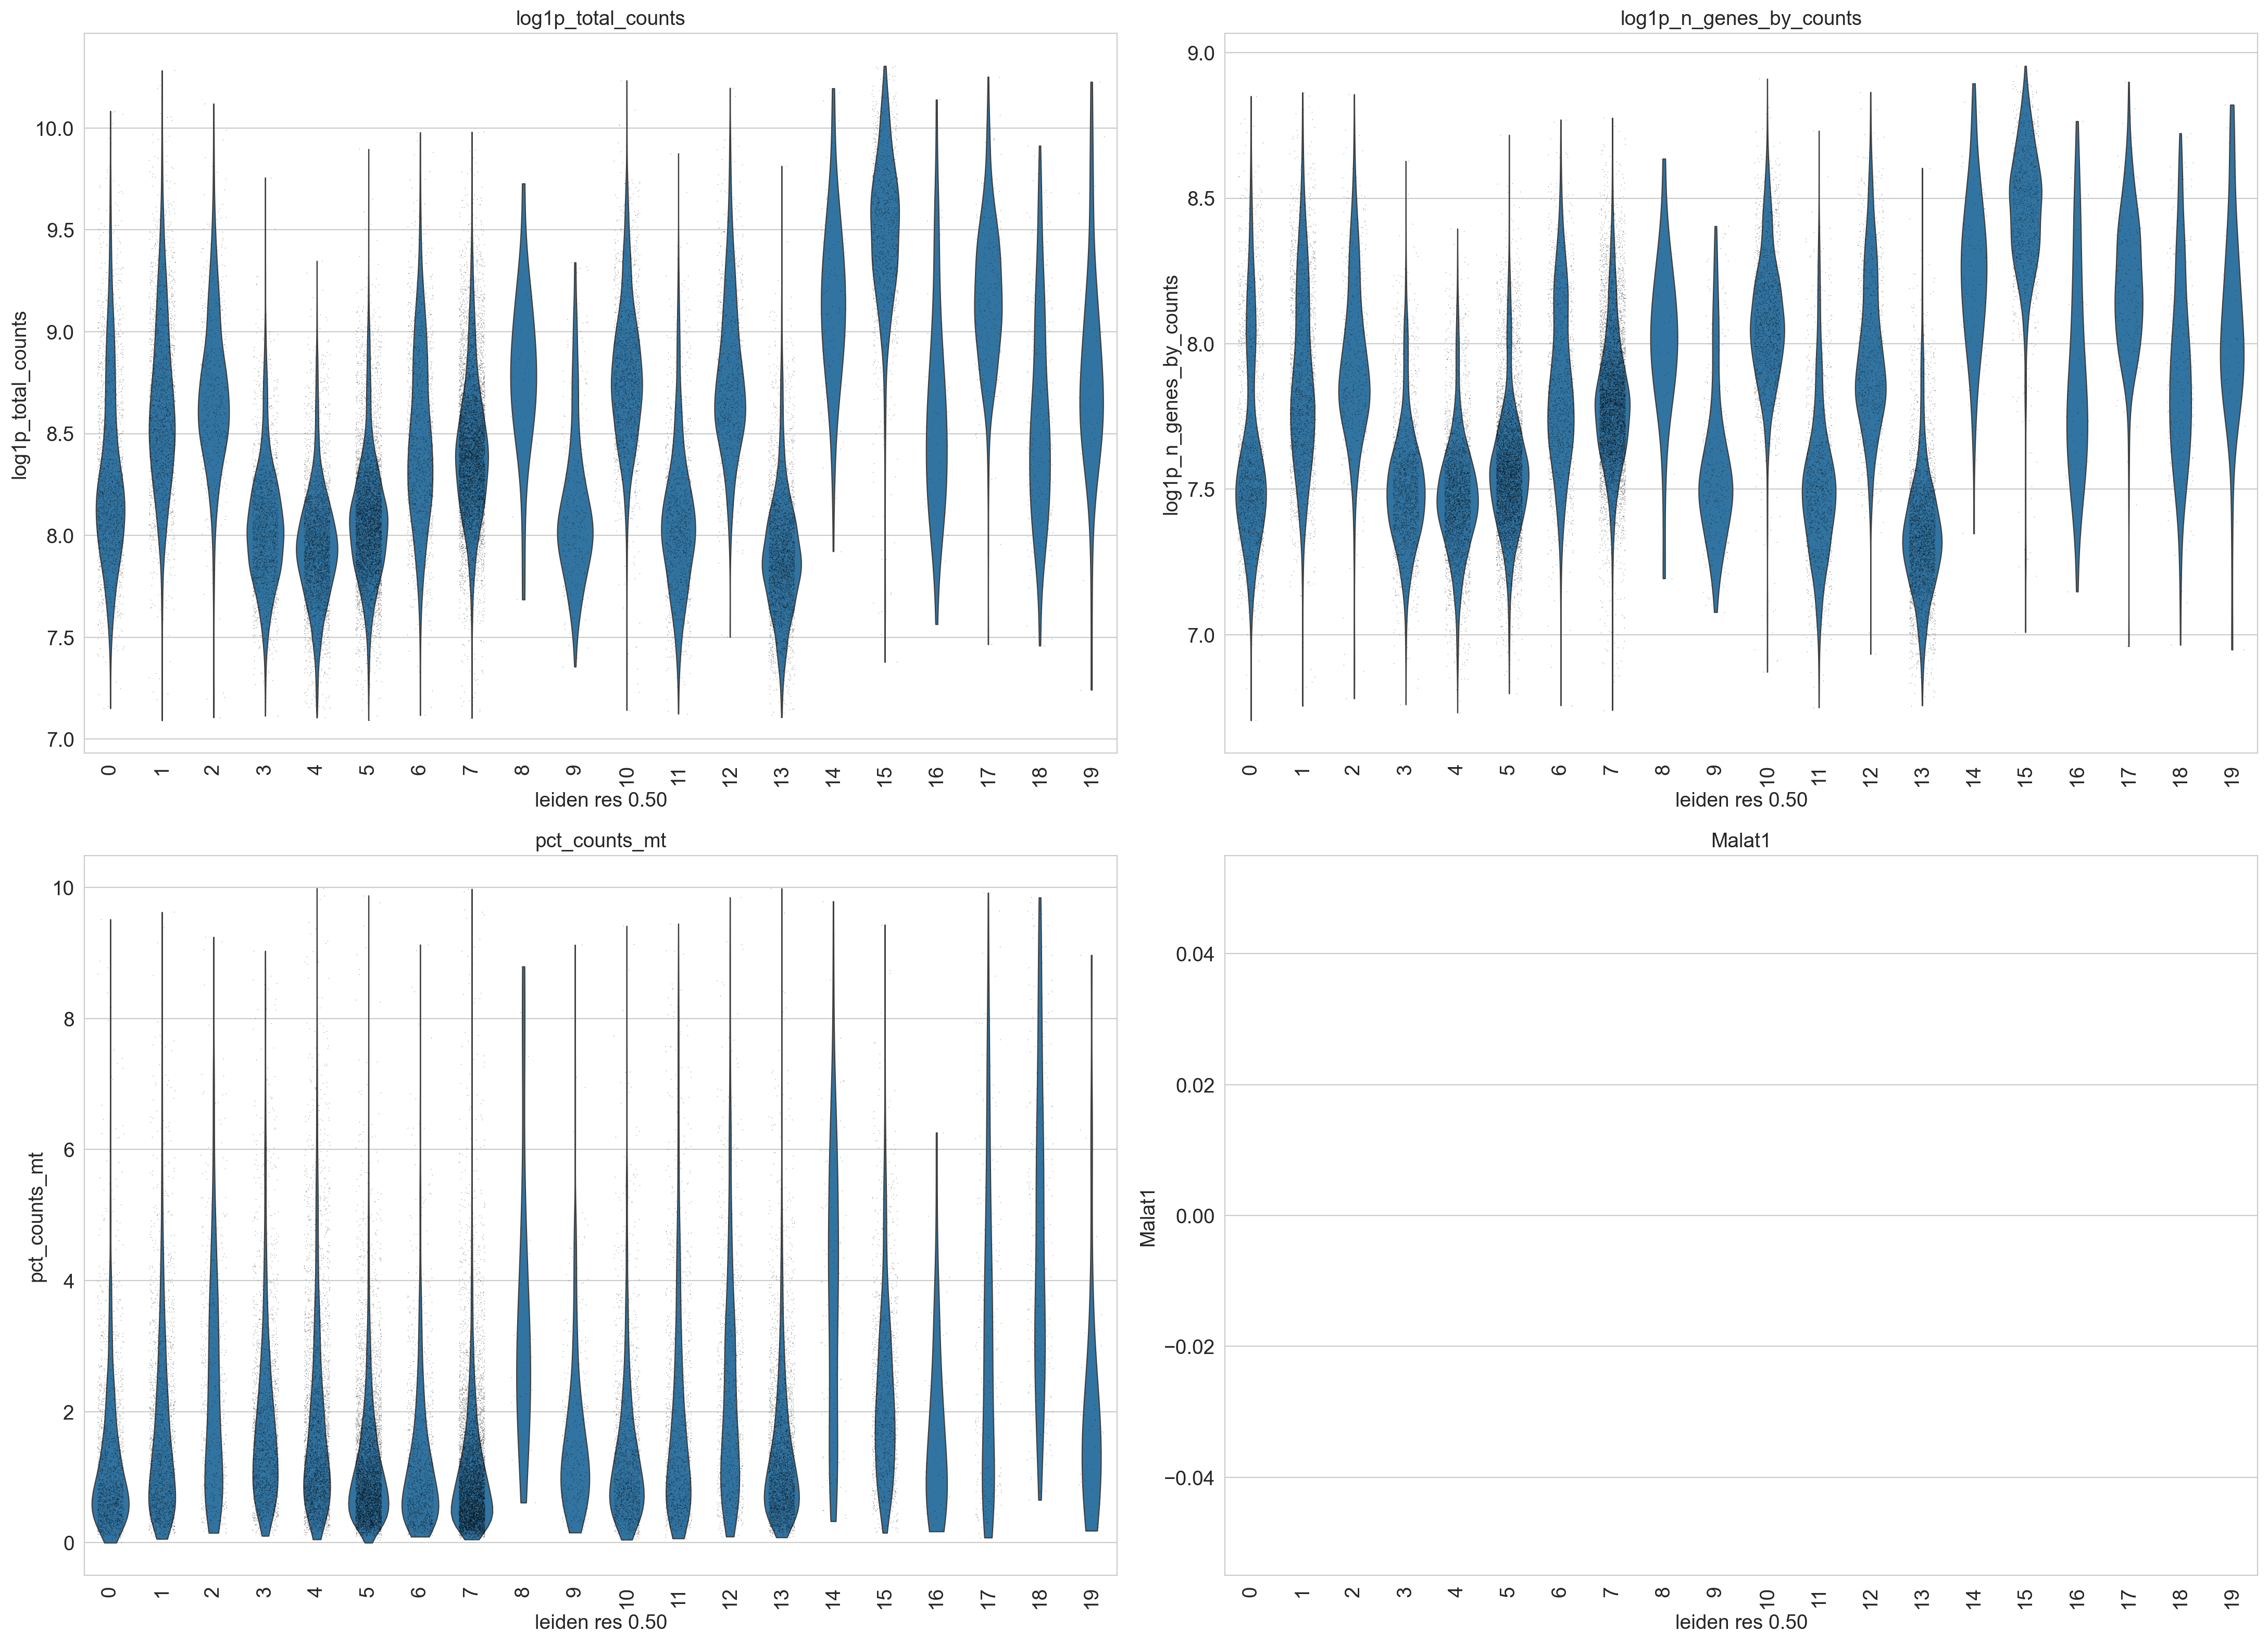

In [12]:
import scipy.sparse as sp


def get_gene_vector(adata, gene):
    values = adata[:, gene].X
    if sp.issparse(values):
        values = values.toarray()
    return values.ravel()


detailed_qc = adata.obs[[
    CLUSTER_KEY,
    "log1p_total_counts",
    "log1p_n_genes_by_counts",
    "pct_counts_mt",
]].copy()
detailed_qc["cluster_label"] = detailed_qc[CLUSTER_KEY].astype(str)

if "Malat1" in adata.var_names:
    detailed_qc["Malat1"] = get_gene_vector(adata, "Malat1")

cluster_order = sorted(detailed_qc["cluster_label"].unique(), key=lambda x: int(x))
qc_metrics = ["log1p_total_counts", "log1p_n_genes_by_counts", "pct_counts_mt"]
if "Malat1" in detailed_qc.columns:
    qc_metrics.append("Malat1")

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
axes = axes.flatten()

for ax, metric in zip(axes, qc_metrics):
    sns.violinplot(
        data=detailed_qc,
        x="cluster_label",
        y=metric,
        order=cluster_order,
        inner=None,
        cut=0,
        linewidth=0.8,
        ax=ax,
    )
    sns.stripplot(
        data=detailed_qc,
        x="cluster_label",
        y=metric,
        order=cluster_order,
        color="black",
        size=0.6,
        alpha=0.35,
        jitter=0.25,
        ax=ax,
    )
    ax.set_title(metric)
    ax.set_xlabel(CLUSTER_KEY.replace("_", " "))
    ax.tick_params(axis="x", rotation=90)

for ax in axes[len(qc_metrics):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
cluster_filter_review = (
    detailed_qc
    .groupby(CLUSTER_KEY, observed=True)
    .agg(
        n_cells=("log1p_total_counts", "size"),
        median_log1p_total_counts=("log1p_total_counts", "median"),
        median_log1p_n_genes=("log1p_n_genes_by_counts", "median"),
        median_pct_mt=("pct_counts_mt", "median"),
        q75_pct_mt=("pct_counts_mt", lambda x: x.quantile(0.75)),
        mean_doublet_score=("pct_counts_mt", lambda x: adata.obs.loc[x.index, "doublet_score"].mean()),
    )
)

if "Malat1" in detailed_qc.columns:
    cluster_filter_review = cluster_filter_review.join(
        detailed_qc.groupby(CLUSTER_KEY, observed=True)["Malat1"].median().rename("median_Malat1")
    )

cluster_filter_review = cluster_filter_review.round(2)
cluster_filter_review["candidate_low_complexity"] = (
    cluster_filter_review["median_log1p_total_counts"] < cluster_filter_review["median_log1p_total_counts"].quantile(0.10)
) | (
    cluster_filter_review["median_log1p_n_genes"] < cluster_filter_review["median_log1p_n_genes"].quantile(0.10)
)
cluster_filter_review["candidate_high_mt"] = cluster_filter_review["median_pct_mt"] > 8
cluster_filter_review.to_csv(CLUSTERING_DIR / "02_cluster_manual_filter_review.csv")
cluster_filter_review

,n_cells,median_log1p_total_counts,median_log1p_n_genes,median_pct_mt,q75_pct_mt,mean_doublet_score,median_Malat1,candidate_low_complexity,candidate_high_mt
leiden_res_0.50,,,,,,,,,
0,2060,8.21,7.54,0.90,1.63,0.05,NaN,False,False
1,2150,8.59,7.83,1.29,2.32,0.08,NaN,False,False
2,650,8.67,7.90,1.90,3.32,0.07,NaN,False,False
3,2208,8.02,7.49,1.53,2.42,0.02,NaN,False,False
4,3591,7.93,7.47,1.36,2.38,0.03,NaN,True,False
5,5865,8.06,7.55,0.93,1.57,0.05,NaN,False,False
6,1502,8.43,7.82,0.90,1.57,0.06,NaN,False,False
7,6927,8.39,7.79,0.86,1.48,0.05,NaN,False,False
8,23,8.79,8.03,2.75,4.18,0.04,NaN,False,False


## Retinal marker inspection

In [14]:
marker_genes = {
    "Rod": ["Rho", "Gnat1", "Pde6a", "Pde6b", "Cnga1", "Nr2e3", "Nrl", "Prph2", "Rom1"],
    "Cone": ["Pde6h", "Arr3", "Opn1mw", "Gnat2", "Pde6c", "Opn1sw"],
    "BC": ["Vsx1", "Vsx2", "Car10", "Otx2os1", "Gng13", "Nrxn3", "Gabrb3", "Trnp1", "Kcnma1", "Frmd3", "Gm4792", "Nyap2"],
    "AC": ["Tfap2a", "Tfap2b", "Pax6", "Frmd5", "Nrg3", "Elavl3", "Gad1", "Gad2"],
    "MG": ["Rlbp1", "Glul", "Dkk3", "Adamtsl1", "Gpr37", "Abca8a", "Rgs6", "Spc25", "Clu", "Apoe", "Aqp4"],
    "HC": ["Calb1", "Onecut1", "Slc4a3", "Onecut2", "Gm45459", "C1ql1"],
    "RGC": ["Nefl", "Stmn2", "Nrn1", "Pou4f1", "Pou4f2", "Sncg", "Stmn2", "Rbpms"],
    "RPE": ["Ttr", "Rdh5", "Rgr", "Slc16a8"],
    "Astrocyte": ["S100b", "Gfap", "Mlc1", "Prdx6", "Pdgfra"],
    "Microglia": ["Ctss", "C1qa", "Hexb", "Trem2"],
    "Endothelial": ["Cldn5", "Flt1", "Ly6c1", "Ptprb"],
}

available_marker_genes = {
    cell_type: [gene for gene in genes if gene in adata.var_names]
    for cell_type, genes in marker_genes.items()
}
available_marker_genes

{'Rod': ['Rho',
  'Gnat1',
  'Pde6a',
  'Pde6b',
  'Cnga1',
  'Nr2e3',
  'Nrl',
  'Prph2',
  'Rom1'],
 'Cone': ['Pde6h', 'Arr3', 'Opn1mw', 'Gnat2', 'Pde6c', 'Opn1sw'],
 'BC': ['Vsx1',
  'Vsx2',
  'Car10',
  'Otx2os1',
  'Gng13',
  'Nrxn3',
  'Gabrb3',
  'Trnp1',
  'Kcnma1',
  'Frmd3',
  'Gm4792',
  'Nyap2'],
 'AC': ['Tfap2a', 'Tfap2b', 'Pax6', 'Frmd5', 'Nrg3', 'Elavl3', 'Gad1', 'Gad2'],
 'MG': ['Rlbp1',
  'Glul',
  'Dkk3',
  'Adamtsl1',
  'Gpr37',
  'Abca8a',
  'Rgs6',
  'Spc25',
  'Clu',
  'Apoe',
  'Aqp4'],
 'HC': ['Calb1', 'Onecut1', 'Slc4a3', 'Onecut2', 'Gm45459', 'C1ql1'],
 'RGC': ['Nefl',
  'Stmn2',
  'Nrn1',
  'Pou4f1',
  'Pou4f2',
  'Sncg',
  'Stmn2',
  'Rbpms'],
 'RPE': ['Ttr', 'Rdh5', 'Rgr', 'Slc16a8'],
 'Astrocyte': ['S100b', 'Gfap', 'Mlc1', 'Prdx6', 'Pdgfra'],
 'Microglia': ['Ctss', 'C1qa', 'Hexb', 'Trem2'],
 'Endothelial': ['Cldn5', 'Flt1', 'Ly6c1', 'Ptprb']}

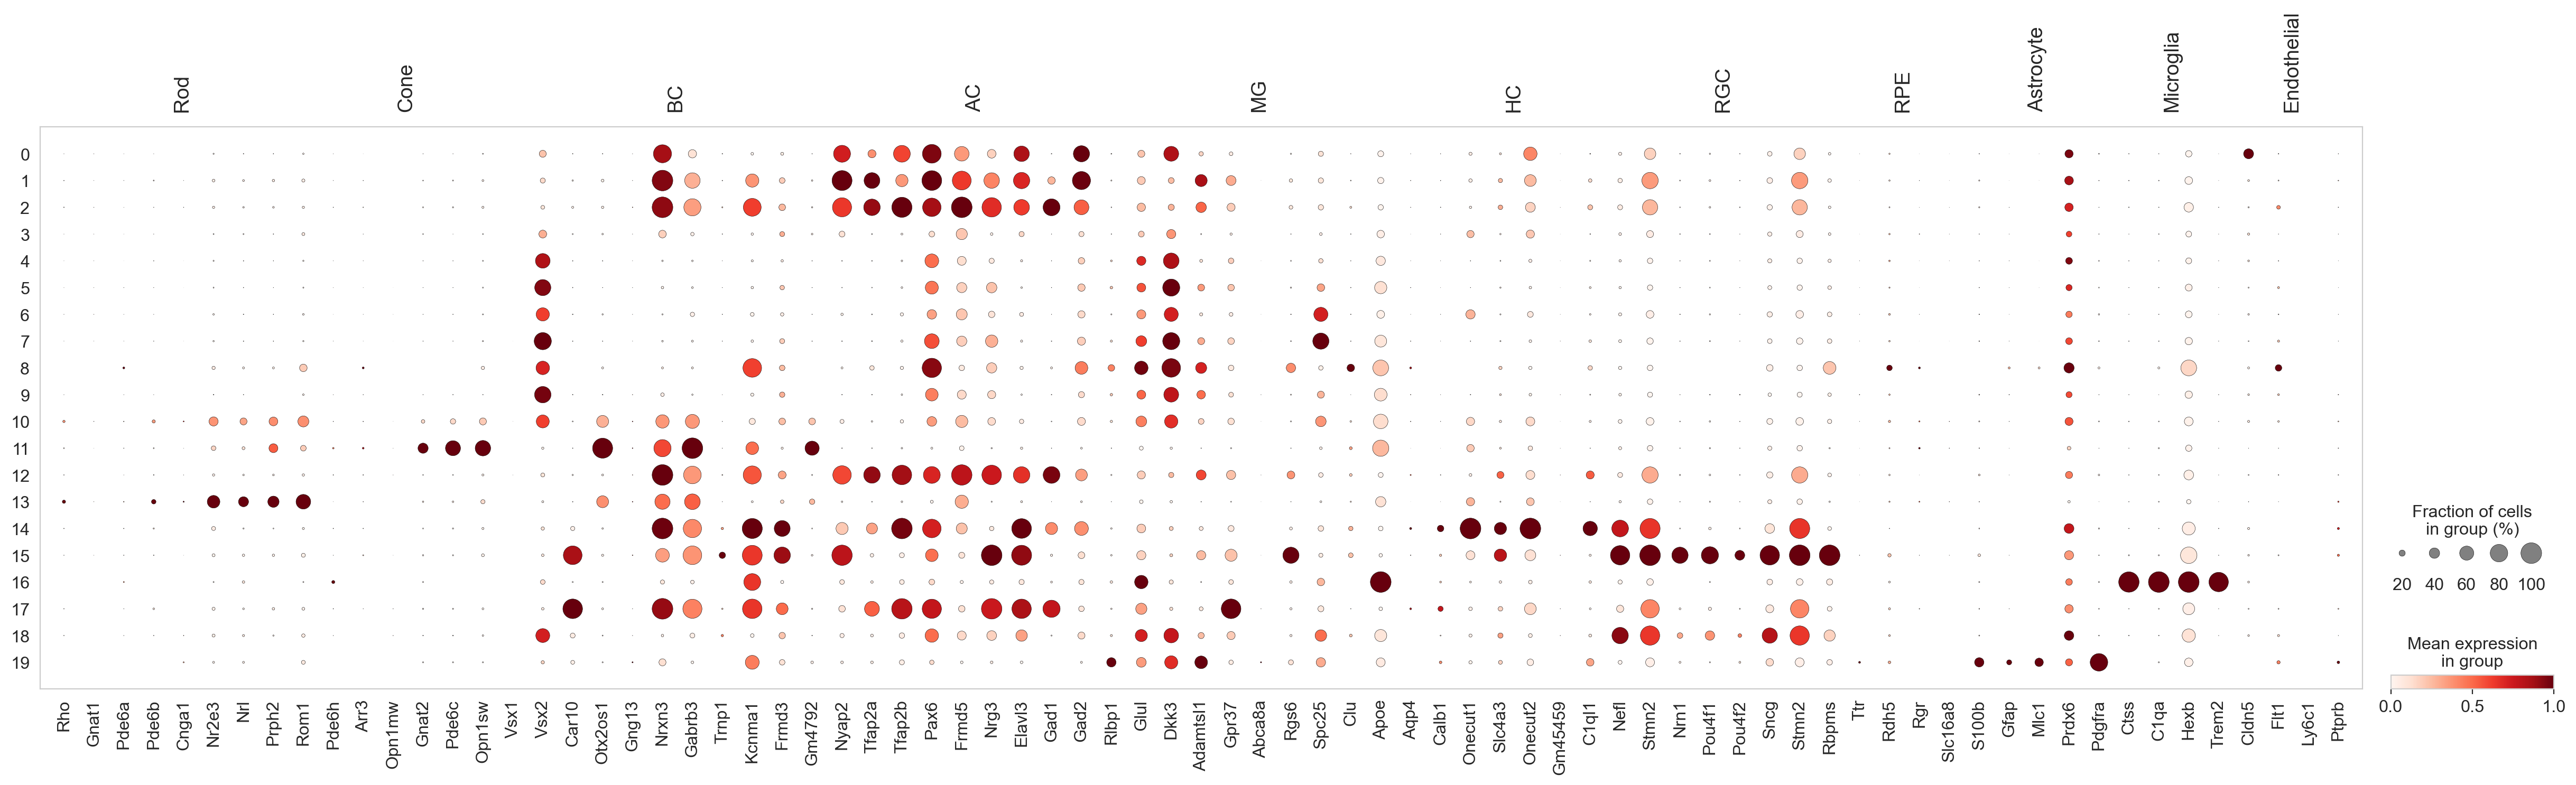

In [15]:
sc.pl.dotplot(adata, available_marker_genes, groupby=CLUSTER_KEY, standard_scale="var")

In [16]:
adata.write(OUTPUT_H5AD)
print(f"Saved clustered AnnData: {OUTPUT_H5AD}")

Saved clustered AnnData: /Users/louis/Desktop/lab/code/scrna/day0_insm1_scrna/data/interim/02_clustered.h5ad
